In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

from mplsoccer import Sbopen, Pitch, VerticalPitch
from adjustText import adjust_text

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

parser = Sbopen()
df_competition = parser.competition()

# 경기 이벤트 데이터 불러오기
df_event, df_realted, df_freeze, df_tactics = parser.event(3857299)

# 대한민국 데이터만 필터링 (대괄로 감싸는건 필수)
df_kor_event = df_event[df_event['team_name'] == 'South Korea']

# 가나 데이터만 필터링 
df_gn_event = df_event[df_event['team_name'] == 'Ghana']
# 이벤트 개수 확인
print(len(df_kor_event))
print(len(df_gn_event))


2008
1338


In [2]:
# 교체 발생 필터링
kor_sub_events = df_kor_event[df_kor_event['type_name'] == 'Substitution']
gn_sub_events = df_gn_event[df_gn_event['type_name'] == "Substitution"]

# 첫 교체 시간 구하기
first_kor_sub_min = kor_sub_events.iloc[0]['minute']
first_gn_sub_min = gn_sub_events.iloc[0]['minute']

print(f"대한민국 첫 교체 시간: {first_kor_sub_min}분")
print(f"가나 첫 교체 시간: {first_gn_sub_min}분")

대한민국 첫 교체 시간: 45분
가나 첫 교체 시간: 77분


In [3]:
# 첫 교제 대신 실제 전반전, 후반전 전체로 다시 필터링

kor_first_half = df_kor_event[df_kor_event['period'] == 1]
gn_first_half = df_gn_event[df_gn_event['period'] == 1]

kor_second_half = df_kor_event[df_kor_event['period'] == 2]
gn_second_half = df_gn_event[df_gn_event['period'] == 2]

kor_passes_h1 = kor_first_half[
    (df_kor_event['type_name'] == 'Pass') &
    (df_kor_event['outcome_name'].isna())
]
gn_passes_h1 = gn_first_half[
    (df_gn_event['type_name'] == 'Pass') &
    (df_gn_event['outcome_name'].isna())
]

print(f"대한민국 전반전 성공 패스 수: {len(kor_passes_h1)}")
print(f"가나 전반전 성공 패스 수: {len(gn_passes_h1)}")

대한민국 전반전 성공 패스 수: 252
가나 전반전 성공 패스 수: 166


In [4]:
# 대한민국 선수별 평균 좌표 계산하기
kor_player_coords = kor_passes_h1.groupby('player_name')[['x', 'y']].mean().reset_index()
# 가나 선수별 평균 좌표 계산하기
gn_player_coords = gn_passes_h1.groupby('player_name')[['x', 'y']].mean().reset_index() 

print(f'대한민국 선발 인원수: {len(kor_player_coords)}명')
print(f'가나 선발 인원수: {len(gn_player_coords)}명')

대한민국 선발 인원수: 11명
가나 선발 인원수: 11명


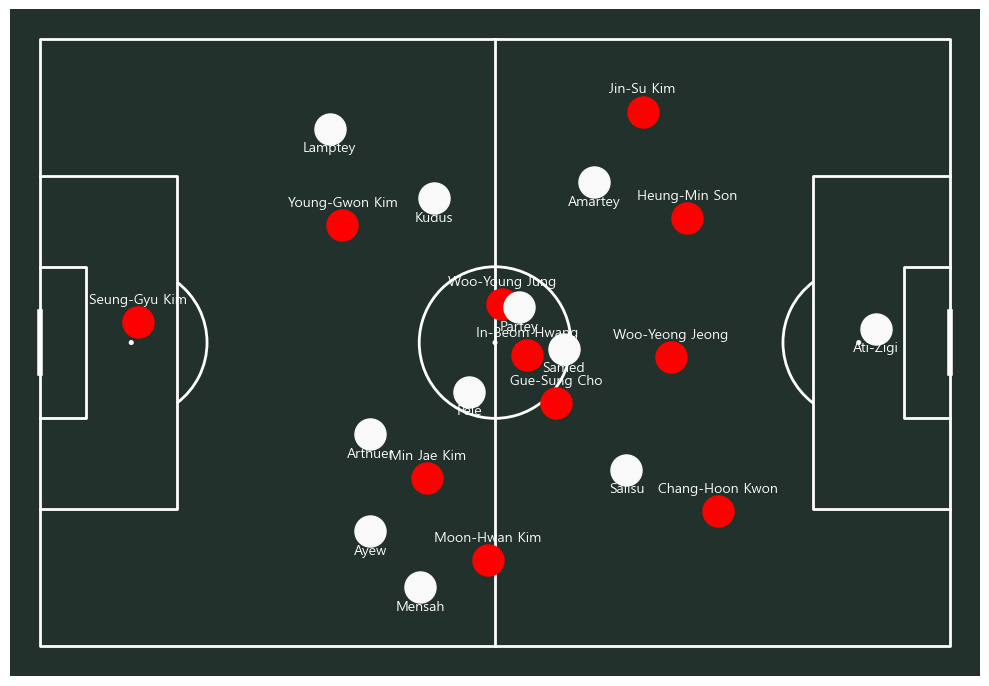

In [5]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 1. 대한민국 (붉은색 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax
    )

# 1-1. 가나 (흰색 점 찍기)
pitch.scatter(
    120-gn_player_coords['x'], 
    80-gn_player_coords['y'], 
    s=500, 
    color='#f9f9f9', 
    ax=ax
    )

# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] - 2.5),
        c='white', ha='center', ax= ax
    )
# 2-1. 가나 선수 이름 표시 
for idx, row in gn_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-1],
        xy=(120-row['x'], 80-row['y'] + 3),
        c='white', ha='center', ax= ax
    )  

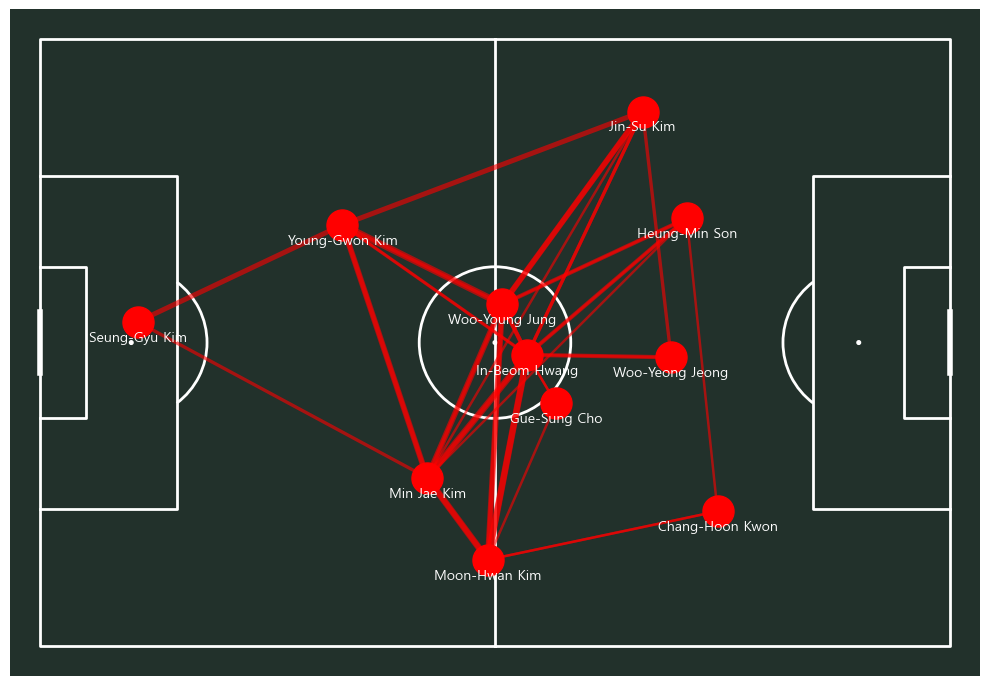

In [6]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# 선수들간의 패스 횟수
kor_passes_between = kor_passes_h1.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')

# 패스 횟수를 1 ~ 2회 정도로 하면 선이 너무 많아져서 지저분해질수 있기때문에 4회 정도로 설정
kor_passes_between = kor_passes_between[kor_passes_between['pass_count'] > 2]

# 패스 횟수 표에 선수들의 평균 좌표(x,y) 합치기
# 1. 패스 보낸 사람(player_name)의 평균 x,y 좌표 붙이기
kor_passes_between = kor_passes_between.merge(kor_player_coords, on='player_name')

# 2. 패스 받은 사람 (pass_recipient_name)의 평균 x,y 좌표 붙이기
# (이때 x, y 컬럼명이 겹치므로 각각 x_end, y_end 같은 이름으로 들어감)
kor_passes_between = kor_passes_between.merge(kor_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))


# 1. 대한민국 (붉은 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax
)
# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] + 2.5),
        c='white', ha='center', ax= ax
)
# 3. 대한민국 패스 연결선
pitch.lines(
    kor_passes_between['x'], kor_passes_between['y'], # 시작점 (패스 보낸 사람 좌표)
    kor_passes_between['x_end'], kor_passes_between['y_end'], # 끝점 (패스 받은 사람 좌표)
    linewidth=kor_passes_between['pass_count'] * 0.6,         # 패스 횟수에 비례해서 선 두께 조절
    color='red',
    alpha=0.6,                                                  # 선 투명도
    ax=ax

)
plt.show()   

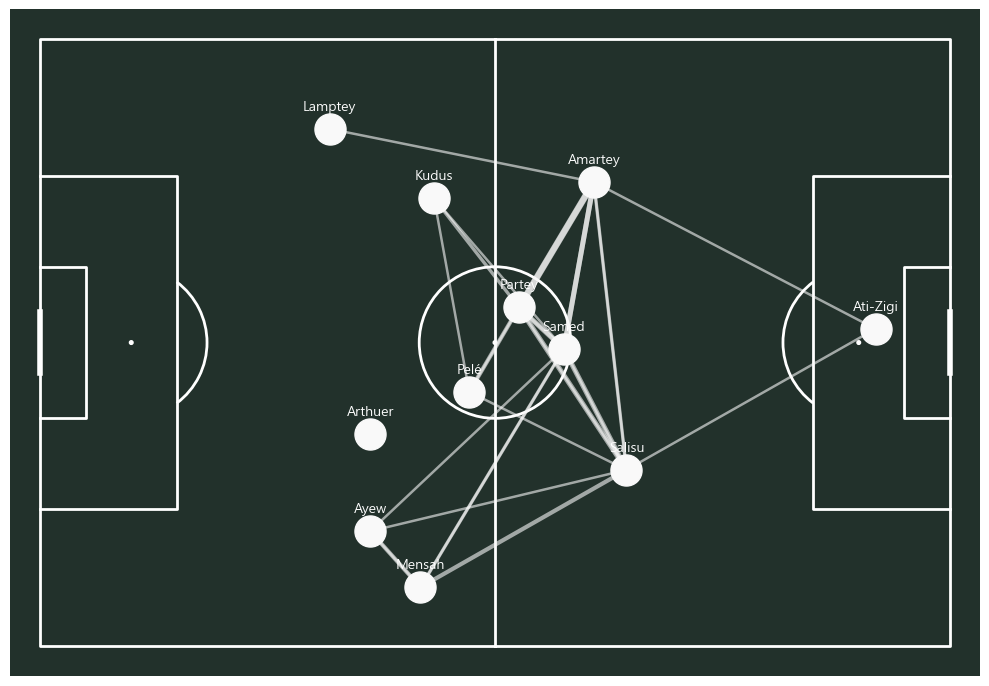

In [7]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 가나 패스맵
gn_passes_between = gn_passes_h1.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')

gn_passes_between = gn_passes_between[gn_passes_between['pass_count'] > 2]

gn_passes_between = gn_passes_between.merge(gn_player_coords, on='player_name')

gn_passes_between = gn_passes_between.merge(gn_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))


# 1. 가나 (흰색 점 찍기)
pitch.scatter(
    120-gn_player_coords['x'], 
    80-gn_player_coords['y'], 
    s=500, 
    color='#f9f9f9', 
    ax=ax
)
# 2. 가나 선수 이름 표시 
for idx, row in gn_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-1],
        xy=(120-row['x'], 80-row['y'] - 2.5),
        c='white', ha='center', ax= ax
)
# 3. 가나 패스 연결선
pitch.lines(
    120-(gn_passes_between['x']), 80-gn_passes_between['y'], #오른쪽에 나타내기위해선 120에서 빼줘야한다.
    120-(gn_passes_between['x_end']), 80-gn_passes_between['y_end'], 
    linewidth=gn_passes_between['pass_count'] * 0.6,         
    color='#f9f9f9',
    alpha=0.6,                                                  
    ax=ax

)    
plt.show()

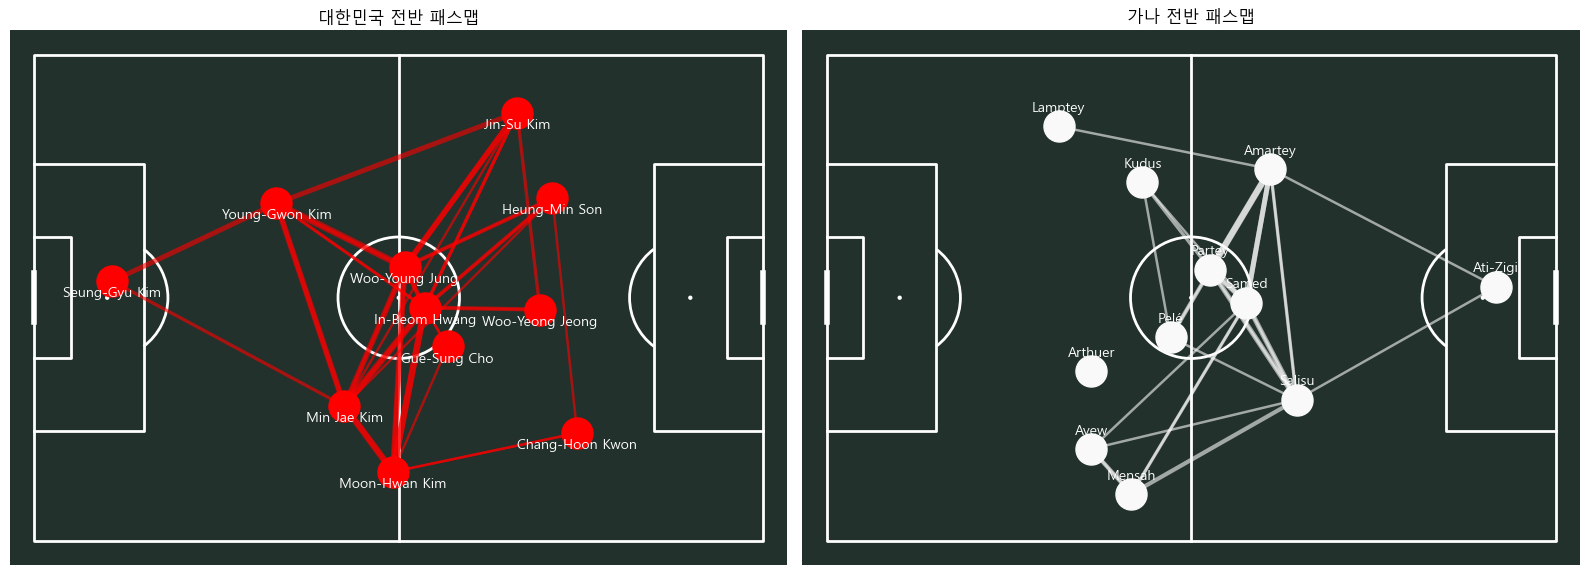

In [8]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')

fig, (ax1, ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))
ax1.set_title('대한민국 전반 패스맵')
ax2.set_title('가나 전반 패스맵')

# 선수들간의 패스 횟수
kor_passes_between = kor_passes_h1.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')
gn_passes_between = gn_passes_h1.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')
# 패스 횟수를 1 ~ 2회 정도로 하면 선이 너무 많아져서 지저분해질수 있기때문에 4회 정도로 설정
kor_passes_between = kor_passes_between[kor_passes_between['pass_count'] > 2]
gn_passes_between = gn_passes_between[gn_passes_between['pass_count'] > 2]
# 패스 횟수 표에 선수들의 평균 좌표(x,y) 합치기
# 1. 패스 보낸 사람(player_name)의 평균 x,y 좌표 붙이기
kor_passes_between = kor_passes_between.merge(kor_player_coords, on='player_name')
gn_passes_between = gn_passes_between.merge(gn_player_coords, on='player_name')
# 2. 패스 받은 사람 (pass_recipient_name)의 평균 x,y 좌표 붙이기
# (이때 x, y 컬럼명이 겹치므로 각각 x_end, y_end 같은 이름으로 들어감)
kor_passes_between = kor_passes_between.merge(kor_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))
gn_passes_between = gn_passes_between.merge(gn_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))

# 1. 대한민국 (붉은 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax1
)
# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] + 2.5),
        c='white', ha='center', ax= ax1
)
# 3. 대한민국 패스 연결선
pitch.lines(
    kor_passes_between['x'], kor_passes_between['y'], # 시작점 (패스 보낸 사람 좌표)
    kor_passes_between['x_end'], kor_passes_between['y_end'], # 끝점 (패스 받은 사람 좌표)
    linewidth=kor_passes_between['pass_count'] * 0.6,         # 패스 횟수에 비례해서 선 두께 조절
    color='red',
    alpha=0.6,                                                  # 선 투명도
    ax=ax1

)

# 1. 가나 (흰색 점 찍기)
pitch.scatter(
    120-gn_player_coords['x'], 
    80-gn_player_coords['y'], 
    s=500, 
    color='#f9f9f9', 
    ax=ax2
)
# 2. 가나 선수 이름 표시 
for idx, row in gn_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-1],
        xy=(120-row['x'], 80-row['y'] - 2.5),
        c='white', ha='center', ax= ax2
)
# 3. 가나 패스 연결선
pitch.lines(
    120-(gn_passes_between['x']), 80-gn_passes_between['y'], #오른쪽에 나타내기위해선 120에서 빼줘야한다.
    120-(gn_passes_between['x_end']), 80-gn_passes_between['y_end'], 
    linewidth=gn_passes_between['pass_count'] * 0.6,         
    color='#f9f9f9',
    alpha=0.6,                                                  
    ax=ax2

)    
plt.show()

In [9]:
# 가나 선수 풀네임 확인용
df_gn_event['player_name'].unique()

# 대한민국 선수 풀네임 확인용
df_kor_event['player_name'].unique()


array([nan, 'Woo-Yeong Jeong', 'Woo-Young Jung', 'Moon-Hwan Kim',
       'Young-Gwon Kim', 'Jin-Su Kim', 'Gue-Sung Cho', 'Min Jae Kim',
       'Seung-Gyu Kim', 'Heung-Min Son', 'Chang-Hoon Kwon',
       'In-Beom Hwang', 'Sang-Ho Na', 'Kang-In Lee', 'Ui-Jo Hwang',
       'Kyung-Won Kwon'], dtype=object)

In [10]:
# 전반 가나 득점 이벤트
gn_goals_h1 = gn_first_half[
    (gn_first_half['type_name'] == 'Shot') &
    (gn_first_half['outcome_name'] == 'Goal')
]

print(gn_goals_h1[['minute', 'player_name', 'x', 'y']])

      minute     player_name      x     y
782       23  Mohamed Salisu  115.5  37.9
1146      33  Mohammed Kudus  113.1  41.8


In [11]:
gn_goals_h1.columns.tolist()

['id',
 'index',
 'period',
 'timestamp',
 'minute',
 'second',
 'possession',
 'duration',
 'match_id',
 'type_id',
 'type_name',
 'possession_team_id',
 'possession_team_name',
 'play_pattern_id',
 'play_pattern_name',
 'team_id',
 'team_name',
 'tactics_formation',
 'player_id',
 'player_name',
 'position_id',
 'position_name',
 'pass_recipient_id',
 'pass_recipient_name',
 'pass_length',
 'pass_angle',
 'pass_height_id',
 'pass_height_name',
 'end_x',
 'end_y',
 'body_part_id',
 'body_part_name',
 'sub_type_id',
 'sub_type_name',
 'x',
 'y',
 'under_pressure',
 'outcome_id',
 'outcome_name',
 'out',
 'off_camera',
 'pass_switch',
 'foul_won_defensive',
 'counterpress',
 'aerial_won',
 'pass_cross',
 'pass_cut_back',
 'pass_assisted_shot_id',
 'pass_shot_assist',
 'shot_statsbomb_xg',
 'shot_key_pass_id',
 'shot_first_time',
 'technique_id',
 'technique_name',
 'goalkeeper_position_id',
 'goalkeeper_position_name',
 'dribble_overrun',
 'block_offensive',
 'pass_deflected',
 'foul_co

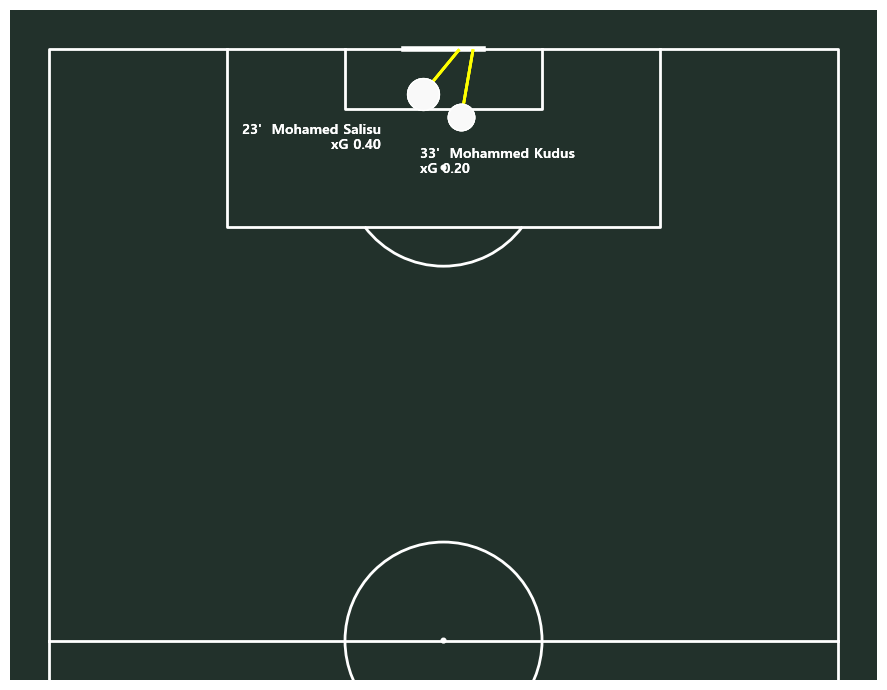

In [12]:
pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white', half=True)
fig, ax = pitch.draw(figsize=(10, 7))

for idx, row in gn_goals_h1.iterrows():
    # 1. 골 위치 점 찍기 (xG 값에 비례해서 점 크기 조절)
    xg = row['shot_statsbomb_xg']
    pitch.scatter(row['x'], row['y'], s=800*xg + 200, color='#f9f9f9',
                  edgecolors='white', ax=ax, zorder=3)

    # 2. 슈팅 궤적: 슛 지점 -> 골대 안쪽(end_x, end_y, end_z 컬럼 확인 필요)
    pitch.lines(row['x'], row['y'], row['end_x'], row['end_y'],
                 color='yellow', ax=ax, lw=2, zorder=2)
    
    offsets = {
    'Mohamed Salisu': {'xytext': (-40, -30), 'ha': 'right'},  # 왼쪽 아래
    'Mohammed Kudus': {'xytext': (-40, -30),  'ha': 'left'},   # 오른쪽 아래
}
    # 3. 라벨: 분, 선수, xG
    for i, (idx, row) in enumerate(gn_goals_h1.iterrows()):
        xg = row['shot_statsbomb_xg']

        pitch.scatter(row['x'], row['y'], s=800*xg + 200, color='#f9f9f9',
                    edgecolors='white', ax=ax, zorder=3)

        pitch.lines(row['x'], row['y'], row['end_x'], row['end_y'],
                    color='yellow', ax=ax, lw=2, zorder=2)

        off = offsets[row['player_name']]
        pitch.annotate(
            text=f"{row['minute']}'  {row['player_name']}\nxG {xg:.2f}",
            xy=(row['x'], row['y']),
            xytext=off['xytext'],
            textcoords='offset points',
            color='white', fontsize=10, weight='bold', ha=off['ha'],
            ax=ax
        )

In [14]:
[c for c in df_gn_event.columns if 'assist' in c.lower() or 'cross' in c.lower()]

gn_assists_h1 = gn_first_half[
    (gn_first_half['type_name'] == 'Pass') &
    (gn_first_half['pass_goal_assist'] == True)
]

print(gn_assists_h1[['minute', 'player_name', 'pass_recipient_name', 'x', 'y', 'end_x', 'end_y', 'pass_cross']])

      minute  player_name pass_recipient_name     x     y  end_x  end_y  \
1144      33  Jordan Ayew      Mohammed Kudus  90.9  10.7  113.1   41.8   

     pass_cross  
1144       True  


In [ ]:
# 이강인 투입 이후 패스만 필터링
lki_passes = df_kor_event[
    (df_kor_event['player_name'] == 'Kang-In Lee') &
    (df_kor_event['type_name'] == 'Pass')
]

print(f"이강인 패스 수: {len(lki_passes)}")
print(lki_passes['minute'].min(), "~", lki_passes['minute'].max(), "분")

이강인 패스 수: 33
56 ~ 100 분


Text(0.5, 1.0, '이강인 패스맵 (투입 이후) — 성공 24 / 실패 9')

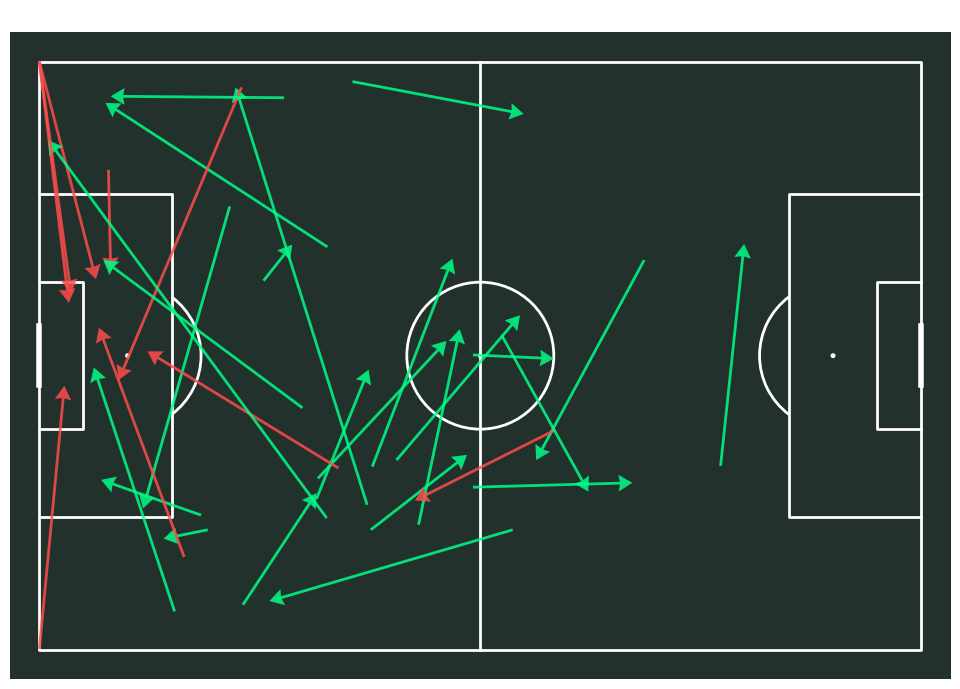

In [20]:
# 이강인 패스맵 (성공/실패 구분)

pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

completed = 0
failed = 0

for idx, row in lki_passes.iterrows():
    is_success = pd.isna(row['outcome_name'])   # outcome_name이 비어있으면 = 성공
    color = '#00ff88' if is_success else '#ff4d4d'

    if is_success:
        completed += 1
    else:
        failed += 1

    pitch.arrows(120-row['x'], 80-row['y'], 120-row['end_x'], 80-row['end_y'],
                 color=color, width=2, headwidth=6, ax=ax, alpha=0.85)

ax.set_title(f"이강인 패스맵 (투입 이후) — 성공 {completed} / 실패 {failed}",
             color='white', fontsize=13)

      minute  player_name pass_recipient_name
2202      57  Kang-In Lee        Gue-Sung Cho


Text(0.5, 1.0, '이강인 패스맵 — 조규성 골 어시스트 강조')

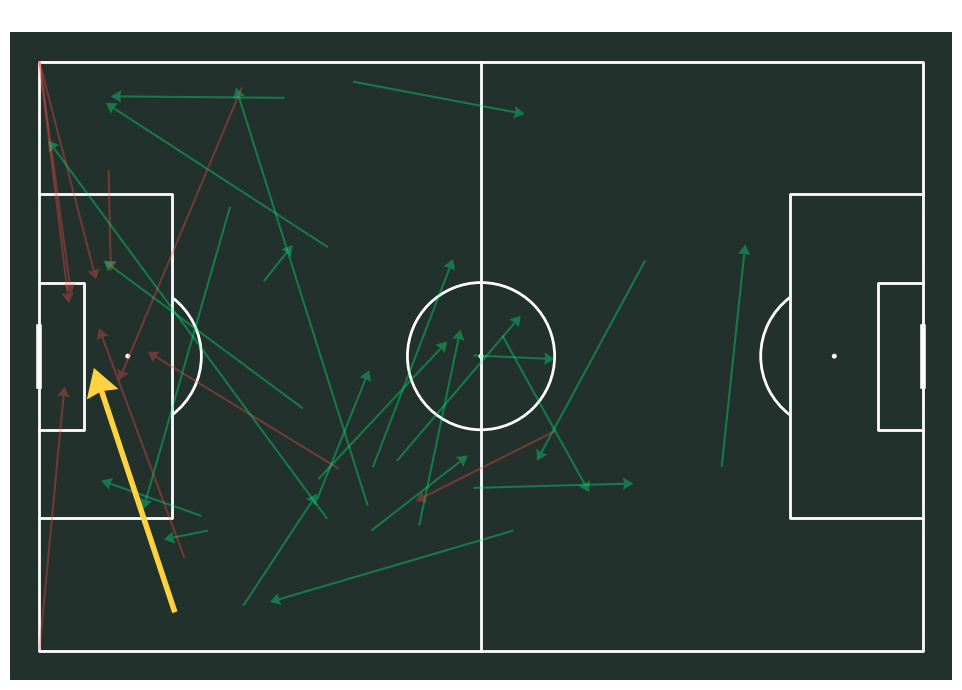

In [23]:
# 조규성 골로 이어진 크로스 강조
# 이강인 패스 중 골로 직접 연결된 것만
lki_assist = lki_passes[lki_passes['pass_goal_assist'] == True]
print(lki_assist[['minute', 'player_name', 'pass_recipient_name']])

pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

for idx, row in lki_passes.iterrows():
    is_assist = row['pass_goal_assist'] == True
    is_success = pd.isna(row['outcome_name'])

    if is_assist:
        color, width, alpha, z = '#ffd23f', 4, 1.0, 5   # 골 어시스트: 노란색 굵게, 맨 위에
    else:
        color = '#00ff88' if is_success else '#ff4d4d'
        width, alpha, z = 1.5, 0.35, 2                   # 나머지: 흐리게

    pitch.arrows(120-row['x'], 80-row['y'], 120-row['end_x'], 80-row['end_y'],
                 color=color, width=width, headwidth=6, ax=ax, alpha=alpha, zorder=z)

ax.set_title("이강인 패스맵 — 조규성 골 어시스트 강조", color='white', fontsize=13)


In [25]:
# 조규성에게 온 크로스 전체 모아보기
cho_targeted_crosses = df_kor_event[
    (df_kor_event['period'] == 2) &
    (df_kor_event['type_name'] == 'Pass') &
    (df_kor_event['pass_recipient_name'] == 'Gue-Sung Cho') &
    (df_kor_event['pass_cross'] == True)
]

print(cho_targeted_crosses[['minute', 'player_name', 'x', 'y', 'end_x', 'end_y', 'pass_goal_assist']])

      minute  player_name      x     y  end_x  end_y pass_goal_assist
2048      52   Jin-Su Kim  110.4   5.8  111.6   36.7              NaN
2202      57  Kang-In Lee  101.6   5.2  112.6   38.4             True
2273      60   Jin-Su Kim  117.9  14.0  115.5   43.7             True
2360      64   Sang-Ho Na   99.5  65.0  109.1   43.7              NaN


Text(0.5, 1.0, "조규성을 겨냥한 크로스 (52'~64') — 크로스 전술 전환의 증거")

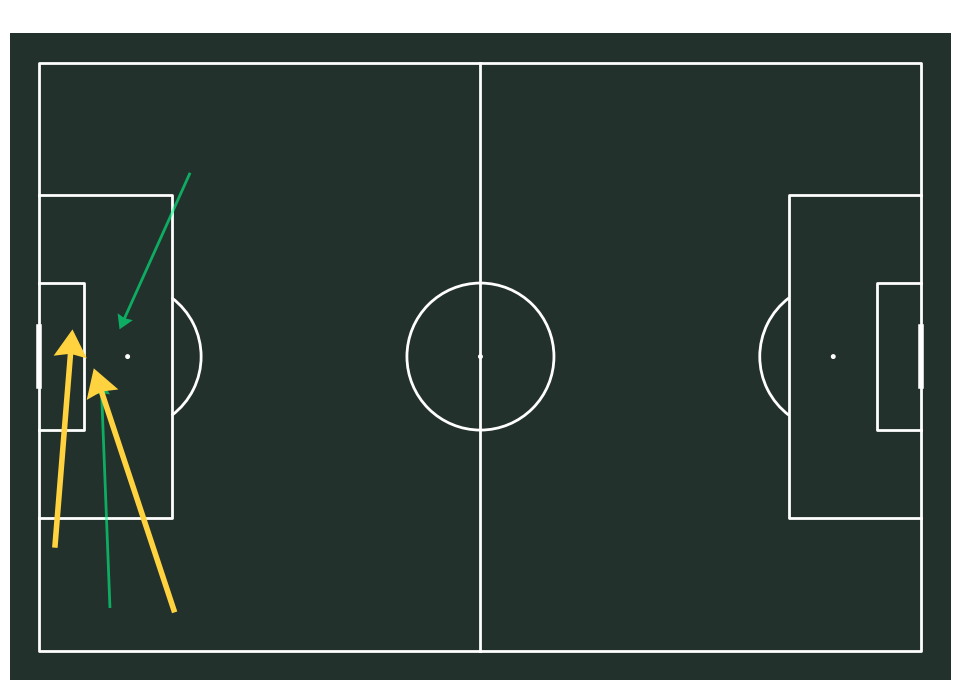

In [32]:
# 조규성에게 온 4개의 크로스
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

for idx, row in cho_targeted_crosses.iterrows():
    is_goal = row['pass_goal_assist'] == True
    color = '#ffd23f' if is_goal else '#00ff88'
    width = 4 if is_goal else 2
    alpha = 1.0 if is_goal else 0.6

    pitch.arrows(120-row['x'], 80-row['y'], 120-row['end_x'], 80-row['end_y'],
                 color=color, width=width, headwidth=6, ax=ax, alpha=alpha, zorder=5 if is_goal else 2)

ax.set_title("조규성을 겨냥한 크로스 (52'~64') — 크로스 전술 전환의 증거", color='white', fontsize=13)

In [34]:
# 조규성 전체 슈팅 필터링

cho_shots = df_kor_event[
    (df_kor_event['player_name'] == 'Gue-Sung Cho') &
    (df_kor_event['type_name'] == 'Shot')
]

print(cho_shots[['minute', 'period', 'x', 'y', 'shot_statsbomb_xg', 'outcome_name']])

      minute  period      x     y  shot_statsbomb_xg outcome_name
130        3       1  111.9  44.7           0.091640      Blocked
559       17       1  115.4  30.4           0.055939      Blocked
2050      52       2  111.6  36.7           0.076775        Saved
2204      57       2  112.6  38.4           0.234844         Goal
2276      60       2  115.5  43.7           0.162371         Goal
3151      93       2  111.6  23.1           0.014337        Saved


Text(0.5, 1.0, '조규성 슈팅맵 vs 가나 — 2골 / xG 합계 0.64')

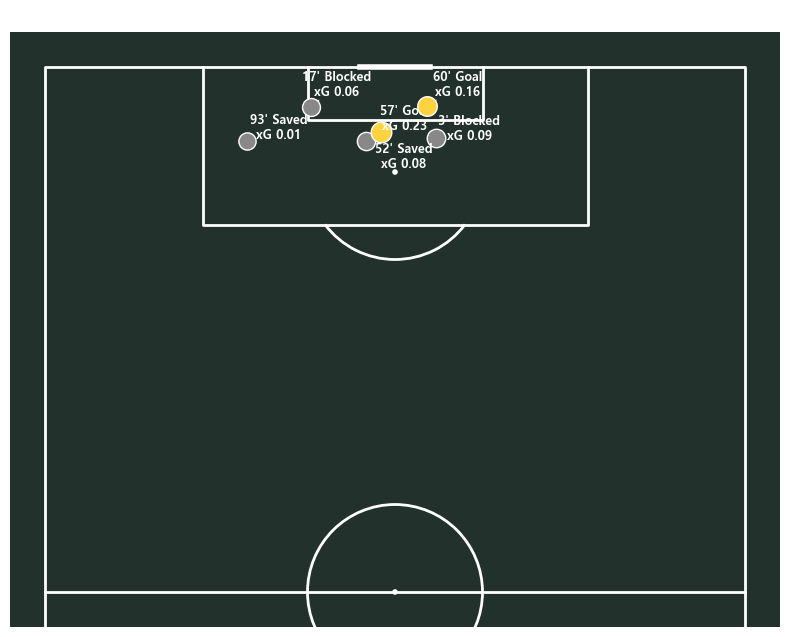

In [59]:
# 조규성 슈팅 맵

pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white', half=True)
fig, ax = pitch.draw(figsize=(8, 8))

texts = []  # 나중에 adjust_text에 넘길 텍스트 객체들을 모아둘 리스트

for idx, row in cho_shots.iterrows():
    is_goal = row['outcome_name'] == 'Goal'
    xg = row['shot_statsbomb_xg']

    color = '#ffd23f' if is_goal else '#888888'
    size = 300 * xg + 150
    pitch.scatter(row['x'], row['y'], s=size, color=color, edgecolors='white', ax=ax, zorder=3)

    # 일단 점 바로 옆(0,0 근처)에 텍스트를 두고, 위치 조정은 adjust_text에 맡긴다
    t = pitch.annotate(
        text=f"{row['minute']}' {row['outcome_name']}\nxG {xg:.2f}",
        xy=(row['x'], row['y']),
        color='white', fontsize=9, weight='bold', ax=ax
    )
    texts.append(t)

# 겹치는 텍스트들을 자동으로 밀어내고, 원래 점까지 화살표로 연결
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='white', lw=0.7))

total_xg = cho_shots['shot_statsbomb_xg'].sum()
n_goals = (cho_shots['outcome_name'] == 'Goal').sum()
ax.set_title(f"조규성 슈팅맵 vs 가나 — {n_goals}골 / xG 합계 {total_xg:.2f}", color='white', fontsize=13)

In [57]:
# 쿠두스 전체 슈팅 필터링
kudus_shots = df_gn_event[
    (df_gn_event['player_name'] == 'Mohammed Kudus') &
    (df_gn_event['type_name'] == 'Shot')
]

print(kudus_shots[['minute', 'period', 'x', 'y', 'shot_statsbomb_xg', 'outcome_name']])

      minute  period      x     y  shot_statsbomb_xg outcome_name
1146      33       1  113.1  41.8           0.200836         Goal
2468      67       2  108.4  48.6           0.154162         Goal


=== 결정력 비교 ===
조규성: 슈팅 6개 / 골 2개 / xG 0.64
쿠두스: 슈팅 2개 / 골 2개 / xG 0.35


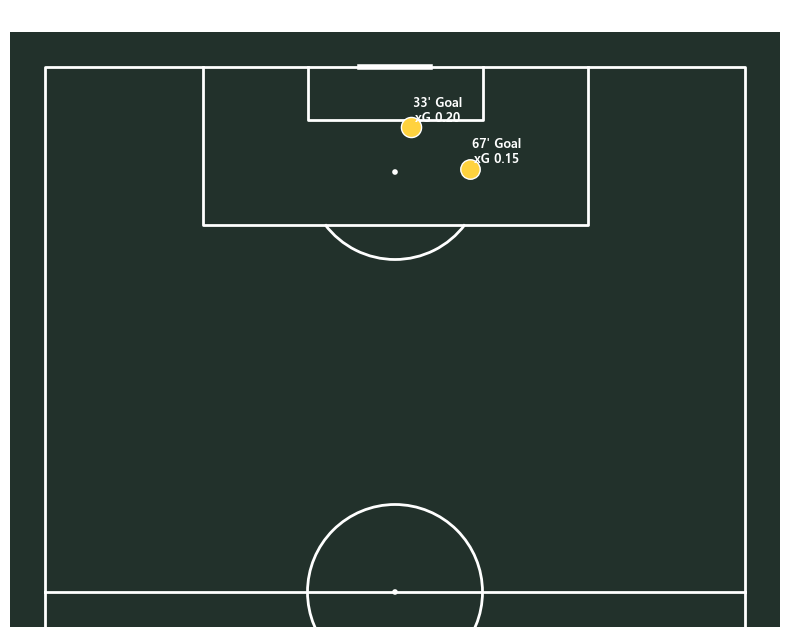

In [62]:
# 쿠두스 슈팅맵
pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white', half=True)
fig, ax = pitch.draw(figsize=(8, 8))

texts = []
for idx, row in kudus_shots.iterrows():
    is_goal = row['outcome_name'] == 'Goal'
    xg = row['shot_statsbomb_xg']

    color = '#ffd23f' if is_goal else '#888888'
    size = 300 * xg + 150
    pitch.scatter(row['x'], row['y'], s=size, color=color, edgecolors='white', ax=ax, zorder=3)

    # 일단 점 바로 옆(0,0 근처)에 텍스트를 두고, 위치 조정은 adjust_text에 맡긴다
    t = pitch.annotate(
        text=f"{row['minute']}' {row['outcome_name']}\nxG {xg:.2f}",
        xy=(row['x'], row['y']),
        color='white', fontsize=9, weight='bold', ax=ax
    )
    texts.append(t)

# 겹치는 텍스트들을 자동으로 밀어내고, 원래 점까지 화살표로 연결
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='white', lw=0.7))

total_xg = kudus_shots['shot_statsbomb_xg'].sum()
n_goals = (kudus_shots['outcome_name'] == 'Goal').sum()
ax.set_title(f"쿠두스 슈팅맵 vs 대한민국 — {n_goals}골 / xG 합계 {total_xg:.2f}", color='white', fontsize=13)

# 조규성 vs 쿠두스 비교 (텍스트로 정리)
print("=== 결정력 비교 ===")
print(f"조규성: 슈팅 {len(cho_shots)}개 / 골 {(cho_shots['outcome_name']=='Goal').sum()}개 / xG {cho_shots['shot_statsbomb_xg'].sum():.2f}")
print(f"쿠두스: 슈팅 {len(kudus_shots)}개 / 골 {(kudus_shots['outcome_name']=='Goal').sum()}개 / xG {kudus_shots['shot_statsbomb_xg'].sum():.2f}")